# Electrical Time Series Data Classification with SimpleRNN

## Prepare Notebook

In [1]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Imports

In [2]:
import os
import numpy as np

from src.utils.visualization import plot_training_history
import src.data.io as data_io
from src.data.split import stratified_split
from src.deployment.export import (
    tflite_to_c_header, 
    export_tflite_int8
)

from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)

from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)
from tensorflow.keras.layers import (
    Input, 
    SimpleRNN, 
    Dense, 
    BatchNormalization, 
    Dropout
)

from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    classification_report
)

## Data Preparation

### Data Loading

In [3]:
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [4]:
train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## SimpleRNN Model

### Building

In [5]:
def build_simplernn(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = SimpleRNN(units=64, return_sequences=True, activation='tanh', unroll=True, kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = SimpleRNN(units=32, return_sequences=False, activation='tanh', unroll=True, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.001))(x)

    model = Model(inputs, outputs)

    return model

simplernn_model = build_simplernn()

simplernn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

simplernn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 5)]           0         
                                                                 
 simple_rnn (SimpleRNN)      (None, 30, 64)            4480      
                                                                 
 batch_normalization (Batch  (None, 30, 64)            256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 30, 64)            0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 32)                3104      
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                            

### Training

In [6]:
def train_simplernn(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_simplernn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_simplernn(simplernn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=32,
                    save_best_model=True)

Epoch 1/50
848/848 [==============================] - 3s 2ms/step - loss: 0.9866 - accuracy: 0.7112 - val_loss: 0.5515 - val_accuracy: 0.8216 - lr: 0.0010
Epoch 2/50
 90/848 [==>...........................] - ETA: 1s - loss: 0.7638 - accuracy: 0.7778

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


848/848 [==============================] - 2s 2ms/step - loss: 0.6920 - accuracy: 0.7945 - val_loss: 0.4556 - val_accuracy: 0.8887 - lr: 0.0010
Epoch 3/50
848/848 [==============================] - 2s 2ms/step - loss: 0.5633 - accuracy: 0.8368 - val_loss: 0.4955 - val_accuracy: 0.8290 - lr: 0.0010
Epoch 4/50
848/848 [==============================] - 2s 2ms/step - loss: 0.5174 - accuracy: 0.8464 - val_loss: 0.3295 - val_accuracy: 0.9118 - lr: 0.0010
Epoch 5/50
848/848 [==============================] - 2s 2ms/step - loss: 0.4740 - accuracy: 0.8615 - val_loss: 0.3192 - val_accuracy: 0.9149 - lr: 0.0010
Epoch 6/50
848/848 [==============================] - 2s 2ms/step - loss: 0.4391 - accuracy: 0.8727 - val_loss: 0.3059 - val_accuracy: 0.9095 - lr: 0.0010
Epoch 7/50
848/848 [==============================] - 2s 2ms/step - loss: 0.4473 - accuracy: 0.8649 - val_loss: 0.3109 - val_accuracy: 0.9115 - lr: 0.0010
Epoch 8/50
848/848 [==============================] - 2s 2ms/step - loss: 0.3899 

## Evaluation

### Training Performance

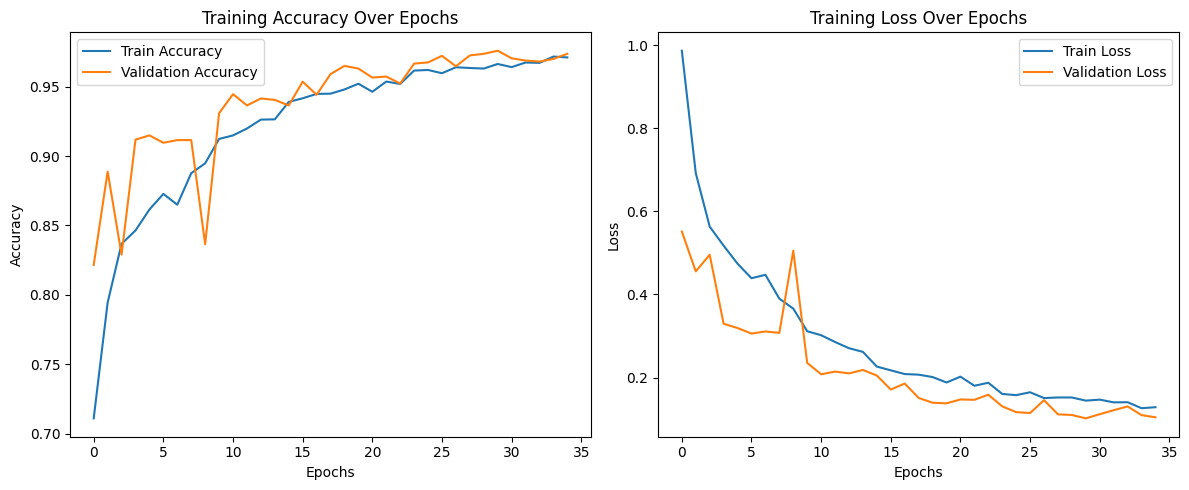

In [7]:
plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 0s 567us/step

Test Accuracy: 0.9803

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9994    0.9992      1789
           1     0.9947    0.9894    0.9920       188
           2     0.9912    0.8898    0.9378       508
           3     0.9915    0.9437    0.9670       373
           4     0.9897    0.9965    0.9931      2603
           5     0.9508    0.9974    0.9736      1938
           6     0.9883    0.9922    0.9902       511
           7     0.9516    0.6020    0.7375        98
           8     0.9537    0.9352    0.9444       463

    accuracy                         0.9803      8471
   macro avg     0.9789    0.9273    0.9483      8471
weighted avg     0.9805    0.9803    0.9796      8471



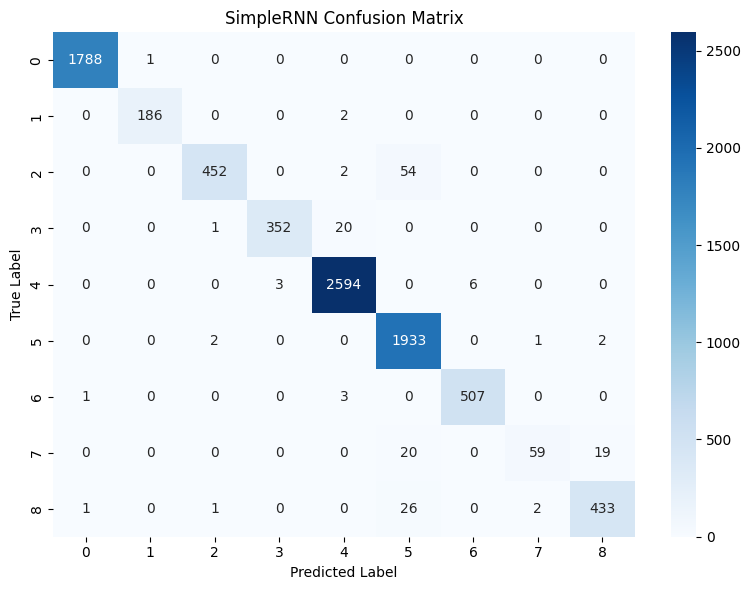

In [8]:
accuracy, report, y_pred = evaluate_classification(
    simplernn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="SimpleRNN Confusion Matrix"
)

### Model Saving and Size Check

In [9]:
simplernn_model.save("../../models/simplernn_model.h5")

model_size = os.path.getsize("../../models/simplernn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 0.16 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [10]:
TFLITE_MODEL_PATH = "../../models/simplernn_model_quantized.tflite"

export_tflite_int8(
    model=simplernn_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpy5xwdm1d/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpy5xwdm1d/assets


Quantized model saved: ../../models/simplernn_model_quantized.tflite (132.79 KB)


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-01 02:41:34.741617: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-01 02:41:34.741632: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-01 02:41:34.741796: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpy5xwdm1d
2026-03-01 02:41:34.744279: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-01 02:41:34.744284: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpy5xwdm1d
2026-03-01 02:41:34.749364: I tensorflow/compiler/m

b' \x00\x00\x00TFL3\x00\x00\x00\x00\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x00\xbc/\x00\x00\xcc/\x00\x00\xe4\x11\x02\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00n\x98\xff\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xff\xa5\x01\x00\x00\x04\x00\x00\x00\x05\x00\x00\x00dense\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00N\x99\xff\xff\x04\x00\x00\x00\x07\x00\x00\x00input_1\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xff\xa8\x01\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00\xa7\x01\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00\xa9\x01\x00\x00\xe0.\x00\x00\xd8.\x00\x00\xc4.\x00\x00\xb0.\x00\x00\x94.\x00\x00\x80.\x00\x00l.\x00\x008.\x00\x00\x08-\x00\x00x,\x00\x00p,\x00\x00h,\x00\x00`,\x00\x00X,\x00\x00P,\x00\x00H,

### Evaluation

In [11]:
interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model prediction completed.


### Test Classification Report

In [12]:
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9601
Precision: 0.9597
Recall: 0.9601
F1-score: 0.9594

Classification Report:
              precision    recall  f1-score   support

           0     0.9803    0.9994    0.9898      1789
           1     0.9777    0.9309    0.9537       188
           2     0.8618    0.8839    0.8727       508
           3     0.9119    0.7775    0.8394       373
           4     0.9869    0.9858    0.9864      2603
           5     0.9597    0.9830    0.9712      1938
           6     0.9733    0.9276    0.9499       511
           7     0.7848    0.6327    0.7006        98
           8     0.8870    0.9158    0.9012       463

    accuracy                         0.9601      8471
   macro avg     0.9248    0.8929    0.9072      8471
weighted avg     0.9597    0.9601    0.9594      8471



### Confusion Matrix

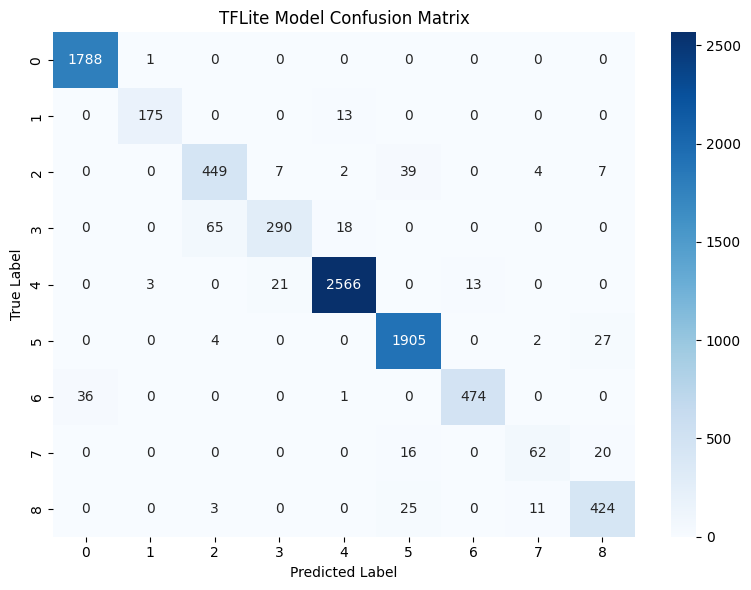

In [13]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [14]:
tflite_model_path = "../../models/simplernn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 132.79 KB


### ESP32 Compatible Header File Creation

In [15]:
tflite_to_c_header(
    "../../models/simplernn_model_quantized.tflite",
    var_name="simplernn_model"
)

C header created: ../../models/simplernn_model_quantized.h
Size: 132.79 KB


PosixPath('../../models/simplernn_model_quantized.h')